In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']


df = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/grouped+isolated/closest_contacts_1mm.csv')



In [2]:
# ===================== CONTACT TYPE TRANSITIONS =====================
# consecutive contact frames (frame t -> t+1) between the same pair in the same video
# every hop in a contact is counted, not just the first one
# row = current contact type, column = next contact type, each row sums to 1
# matrix is made per video, then averaged across videos in each condition
# conditions are the pair types in social_experience
# (tracks 0-4 = socially isolated, tracks 5-9 = group housed)

TYPE_ORDER = ['head_head', 'body_head', 'head_tail', 'body_body', 'body_tail', 'tail_tail']
CONDITIONS = ['GH-GH', 'GH-SI', 'SI-SI']


def video_transition_matrix(d):
    d = d.dropna(subset=['frame', 'Closest Interaction Type'])
    d = d.sort_values(['Interaction Pair', 'frame'])

    prev = d.shift()
    consecutive = (
        (d['Interaction Pair'] == prev['Interaction Pair'])
        & (d['frame'] - prev['frame'] == 1)
    )

    trans = pd.DataFrame({
        'from': prev.loc[consecutive, 'Closest Interaction Type'],
        'to': d.loc[consecutive, 'Closest Interaction Type'],
    })

    if not INCLUDE_SELF:
        trans = trans[trans['from'] != trans['to']]

    counts = pd.crosstab(trans['from'], trans['to']).reindex(index=TYPE_ORDER, columns=TYPE_ORDER, fill_value=0)
    return counts.div(counts.sum(axis=1), axis=0)   # rows with no transitions stay NaN


def condition_matrix(condition):
    d = df[df['social_experience'] == condition]
    per_video = [video_transition_matrix(v) for _, v in d.groupby('file')]
    stacked = np.stack([m.values for m in per_video])
    mean = np.nanmean(stacked, axis=0)   # videos without that current type are ignored for that row
    print(condition, 'videos:', len(per_video), '| contact frames:', len(d))
    return pd.DataFrame(mean, index=TYPE_ORDER, columns=TYPE_ORDER)


def plot_transitions():
    matrices = {c: condition_matrix(c) for c in CONDITIONS}

    mask = None if INCLUDE_SELF else np.eye(len(TYPE_ORDER), dtype=bool)
    vmax = max(np.nanmax(matrices[c].values[~np.eye(len(TYPE_ORDER), dtype=bool)]) if not INCLUDE_SELF
               else np.nanmax(matrices[c].values) for c in CONDITIONS)

    fig, axes = plt.subplots(1, len(CONDITIONS), figsize=(6.5 * len(CONDITIONS), 5.5))

    for i, (ax, c) in enumerate(zip(axes, CONDITIONS)):
        sns.heatmap(
            matrices[c], ax=ax, mask=mask,
            cmap='Blues', vmin=0, vmax=vmax,
            annot=True, fmt='.2f', square=True,
            linewidths=1, linecolor='white',
            cbar=(i == len(CONDITIONS) - 1), cbar_kws={'label': 'P(next type | current type)'},
        )
        ax.set_title(c, fontsize=14, fontweight='bold')
        ax.set_xlabel('Next contact type', fontsize=12, fontweight='bold')
        ax.set_ylabel('Current contact type' if i == 0 else '', fontsize=12, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        ax.tick_params(axis='y', rotation=0)

    fig.suptitle('Including same-type frames' if INCLUDE_SELF else 'Type changes only', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return matrices


GH-GH videos: 12 | contact frames: 4310
GH-SI videos: 12 | contact frames: 5658
SI-SI videos: 12 | contact frames: 1804


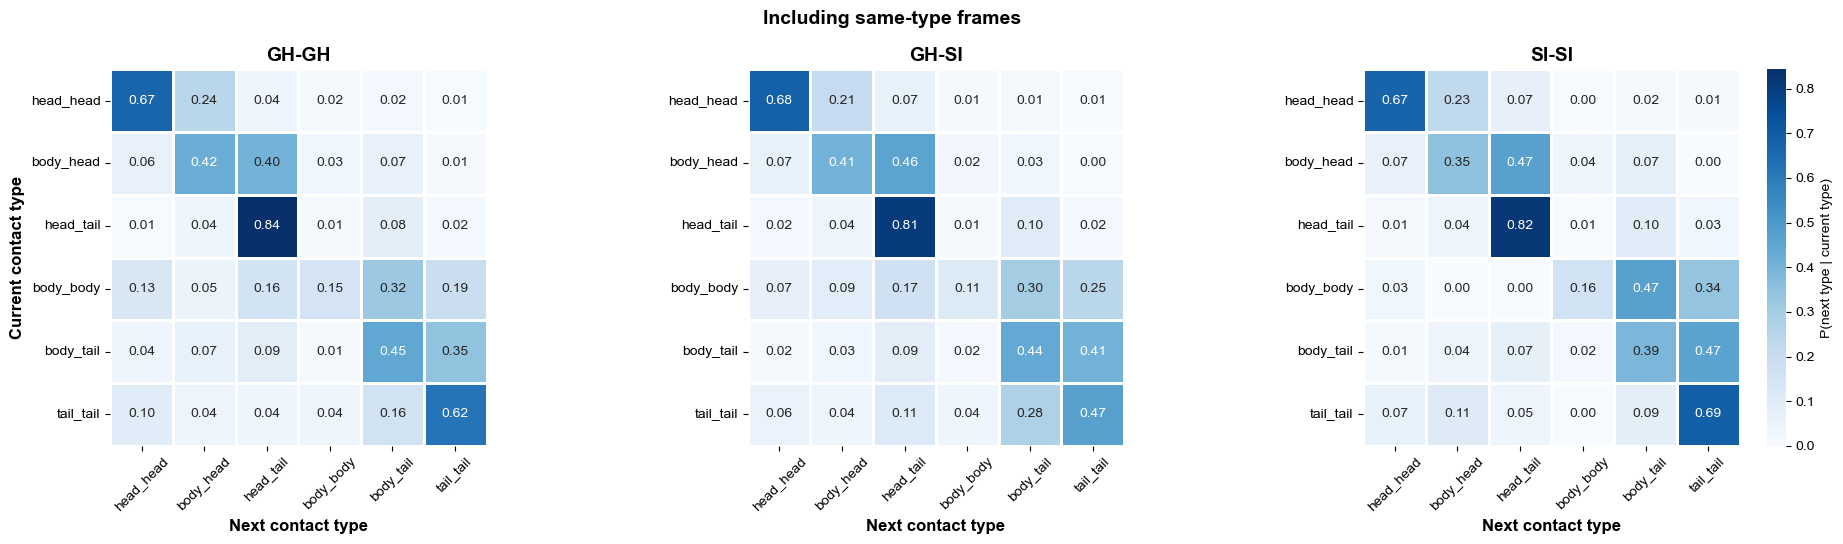

In [3]:
# WITH same-type frames (diagonal = chance the contact stays the same type)
INCLUDE_SELF = True
matrices_with_self = plot_transitions()


GH-GH videos: 12 | contact frames: 4310
GH-SI videos: 12 | contact frames: 5658
SI-SI videos: 12 | contact frames: 1804


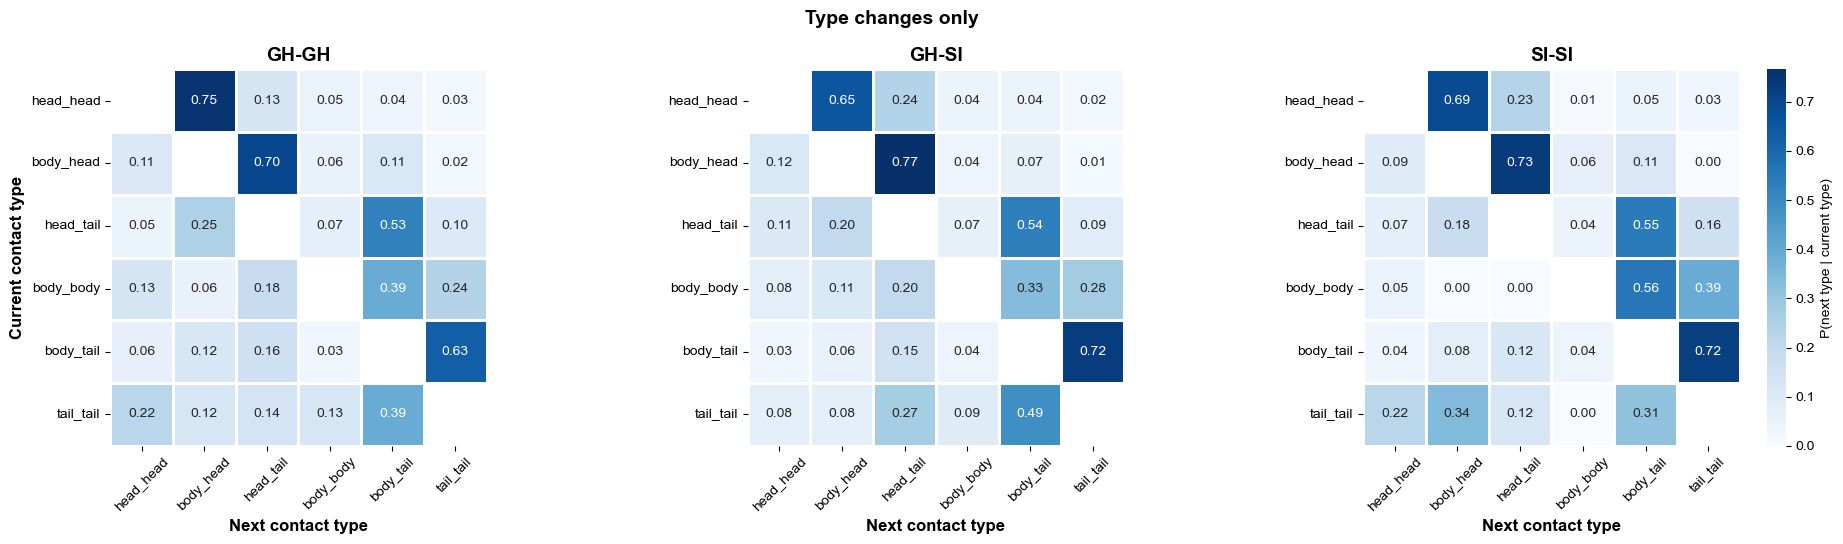

In [4]:
# WITHOUT same-type frames (only what it switches to when it changes)
INCLUDE_SELF = False
matrices_changes_only = plot_transitions()


GH-GH videos: 12 | chunk transitions: 1055
GH-SI videos: 12 | chunk transitions: 1268
SI-SI videos: 12 | chunk transitions: 368


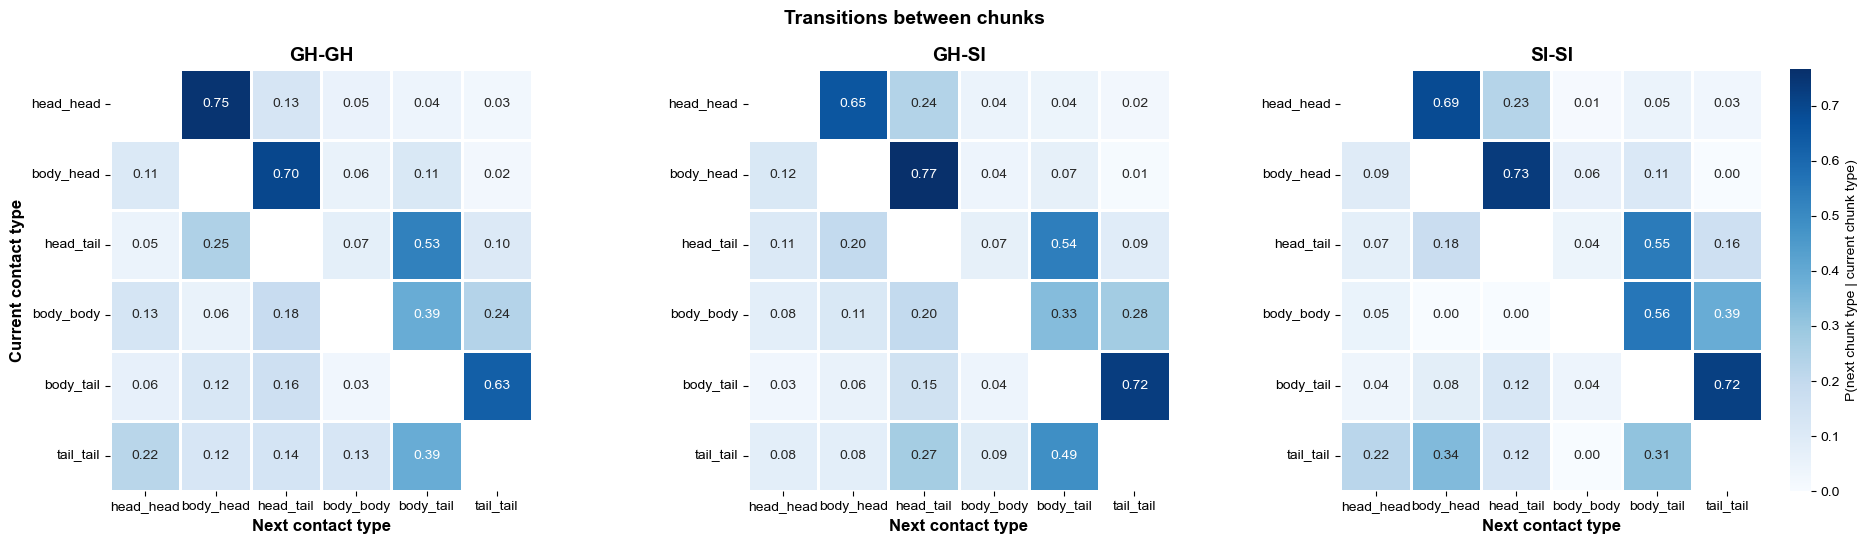

In [5]:
# ===================== CHUNK TRANSITIONS =====================
# a contact = unbroken run of frames (1 frame = 1 s) between the same pair
# within a contact, back-to-back frames of the same type are merged into one chunk
#   e.g. head_head x40 -> body_head x12 -> head_tail x30 = 2 transitions
# row = current chunk type, column = next chunk type, each row sums to 1
# matrix is made per video, then averaged across videos in each condition
# the diagonal is empty by definition (the next chunk is always a different type)


def video_chunk_matrix(d):
    d = d.dropna(subset=['frame', 'Closest Interaction Type'])
    d = d.sort_values(['Interaction Pair', 'frame'])

    prev = d.shift()
    same_contact = (
        (d['Interaction Pair'] == prev['Interaction Pair'])
        & (d['frame'] - prev['frame'] == 1)
    )
    new_chunk = ~same_contact | (d['Closest Interaction Type'] != prev['Closest Interaction Type'])

    contact_id = (~same_contact).cumsum()
    chunk_id = new_chunk.cumsum()

    chunks = (
        d.assign(contact_id=contact_id, chunk_id=chunk_id)
         .groupby('chunk_id')
         .agg(contact_id=('contact_id', 'first'), type=('Closest Interaction Type', 'first'))
    )

    next_chunk = chunks.shift(-1)
    in_same_contact = chunks['contact_id'] == next_chunk['contact_id']

    trans = pd.DataFrame({
        'from': chunks.loc[in_same_contact, 'type'],
        'to': next_chunk.loc[in_same_contact, 'type'],
    })

    counts = pd.crosstab(trans['from'], trans['to']).reindex(index=TYPE_ORDER, columns=TYPE_ORDER, fill_value=0)
    return counts.div(counts.sum(axis=1), axis=0), len(trans)


chunk_matrices = {}

for c in CONDITIONS:
    per_video = [video_chunk_matrix(v) for _, v in df[df['social_experience'] == c].groupby('file')]
    stacked = np.stack([m.values for m, _ in per_video])
    chunk_matrices[c] = pd.DataFrame(np.nanmean(stacked, axis=0), index=TYPE_ORDER, columns=TYPE_ORDER)
    print(c, 'videos:', len(per_video), '| chunk transitions:', sum(n for _, n in per_video))

mask = np.eye(len(TYPE_ORDER), dtype=bool)
vmax = max(np.nanmax(chunk_matrices[c].values[~mask]) for c in CONDITIONS)

fig, axes = plt.subplots(1, len(CONDITIONS), figsize=(6.5 * len(CONDITIONS), 5.5))

for i, (ax, c) in enumerate(zip(axes, CONDITIONS)):
    sns.heatmap(
        chunk_matrices[c], ax=ax, mask=mask,
        cmap='Blues', vmin=0, vmax=vmax,
        annot=True, fmt='.2f', square=True,
        linewidths=1, linecolor='white',
        cbar=(i == len(CONDITIONS) - 1), cbar_kws={'label': 'P(next chunk type | current chunk type)'},
    )
    ax.set_title(c, fontsize=14, fontweight='bold')
    ax.set_xlabel('Next contact type', fontsize=12, fontweight='bold')
    ax.set_ylabel('Current contact type' if i == 0 else '', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0)

fig.suptitle('Transitions between chunks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
